In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Constants

In [2]:
flt_loss_from_dmr = 0.20 # target loss

## Solve for an LGD constant using mean PD

In [3]:
flt_mean_pd = 0.34 # mean of PD predictions
flt_sd_pd = 0.13 # SD of PD predictions

### Create a normal distribution that looks like the PD production predictions

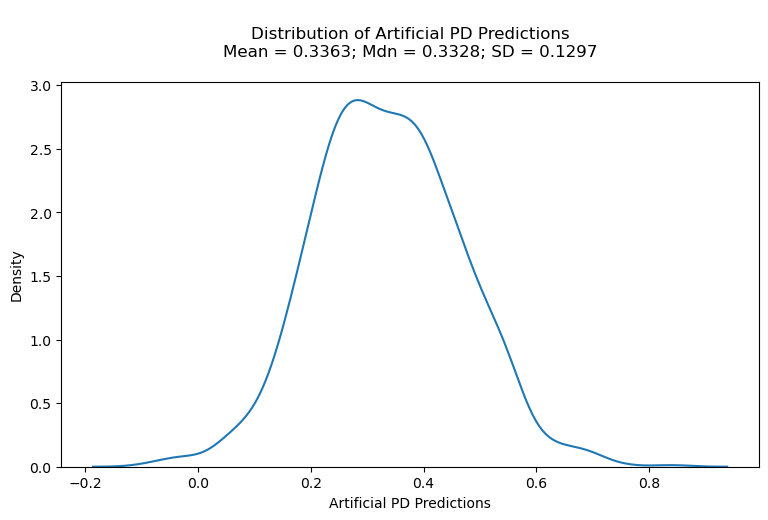

In [4]:
list_flt_pd = list(np.random.normal(loc=flt_mean_pd, scale=flt_sd_pd, size=1000))
flt_mean = np.mean(list_flt_pd)
flt_mdn = np.median(list_flt_pd)
flt_sd = np.std(list_flt_pd)
fig, ax = plt.subplots(figsize=(9,5))
str_title = f"""
Distribution of Artificial PD Predictions
Mean = {flt_mean:0.4}; Mdn = {flt_mdn:0.4f}; SD = {flt_sd:0.4f}
"""
ax.set_title(str_title)
ax.set_xlabel('Artificial PD Predictions')
sns.kdeplot(list_flt_pd, ax=ax)
plt.show()

### Make DF

In [5]:
df = pd.DataFrame({
    'yhat_pd': list_flt_pd,
})
df

,yhat_pd
0,0.287467
1,0.388323
2,0.289419
3,0.383022
4,0.290571
...,...
995,0.458516
996,0.282687
997,0.547795
998,0.340860


### Solve for LGD constant

In [6]:
# solve for LGD
flt_lgd_constant = flt_loss_from_dmr / flt_mean
print(f'LGD Constant: {flt_lgd_constant:0.4f}')

LGD Constant: 0.5948


In [7]:
# assign
df['lgd'] = flt_lgd_constant
df

,yhat_pd,lgd
0,0.287467,0.594785
1,0.388323,0.594785
2,0.289419,0.594785
3,0.383022,0.594785
4,0.290571,0.594785
...,...,...
995,0.458516,0.594785
996,0.282687,0.594785
997,0.547795,0.594785
998,0.340860,0.594785


### Get ECNL

In [8]:
df['ecnl'] = df['yhat_pd'] * df['lgd']
df

,yhat_pd,lgd,ecnl
0,0.287467,0.594785,0.170981
1,0.388323,0.594785,0.230969
2,0.289419,0.594785,0.172142
3,0.383022,0.594785,0.227816
4,0.290571,0.594785,0.172827
...,...,...,...
995,0.458516,0.594785,0.272718
996,0.282687,0.594785,0.168138
997,0.547795,0.594785,0.325820
998,0.340860,0.594785,0.202738


### Plot ECNL

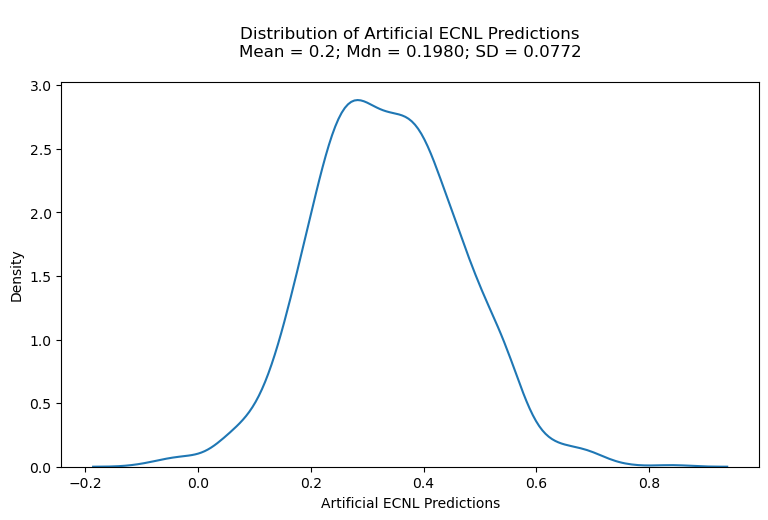

In [9]:
list_flt_ecnl = list(df['ecnl'])
flt_mean = np.mean(list_flt_ecnl)
flt_mdn = np.median(list_flt_ecnl)
flt_sd = np.std(list_flt_ecnl)
fig, ax = plt.subplots(figsize=(9,5))
str_title = f"""
Distribution of Artificial ECNL Predictions
Mean = {flt_mean:0.4}; Mdn = {flt_mdn:0.4f}; SD = {flt_sd:0.4f}
"""
ax.set_title(str_title)
ax.set_xlabel('Artificial ECNL Predictions')
sns.kdeplot(list_flt_pd, ax=ax)
plt.show()

## Can this work using a real LGD value

In [10]:
flt_mean_lgd = 0.41 # mean of PD predictions
flt_sd_lgd = 0.07 # SD of PD predictions

### Create a normal distribution that looks like the LGD production predictions

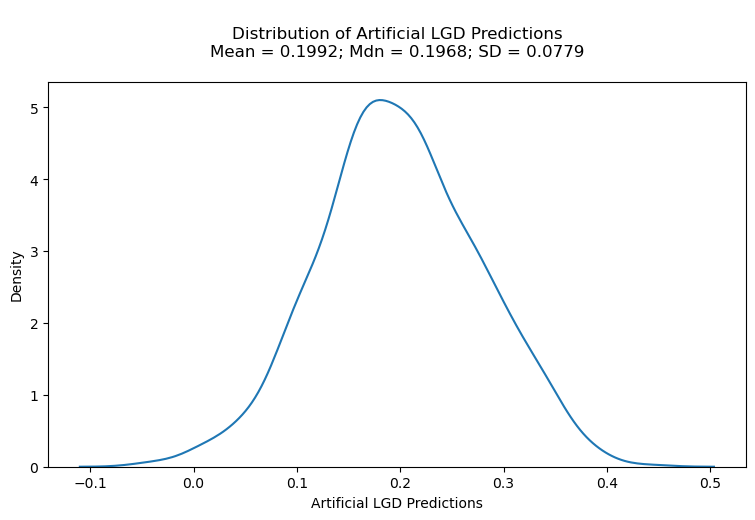

In [11]:
list_flt_lgd = list(np.random.normal(loc=flt_mean, scale=flt_sd, size=1000))
flt_mean = np.mean(list_flt_lgd)
flt_mdn = np.median(list_flt_lgd)
flt_sd = np.std(list_flt_lgd)
fig, ax = plt.subplots(figsize=(9,5))
str_title = f"""
Distribution of Artificial LGD Predictions
Mean = {flt_mean:0.4}; Mdn = {flt_mdn:0.4f}; SD = {flt_sd:0.4f}
"""
ax.set_title(str_title)
ax.set_xlabel('Artificial LGD Predictions')
sns.kdeplot(list_flt_lgd, ax=ax)
plt.show()

### Assign

In [12]:
df.drop('ecnl', axis=1, inplace=True)
df['lgd'] = list_flt_lgd
df

,yhat_pd,lgd
0,0.287467,0.139553
1,0.388323,0.174541
2,0.289419,0.050810
3,0.383022,0.229991
4,0.290571,0.181166
...,...,...
995,0.458516,0.173443
996,0.282687,0.190736
997,0.547795,0.289395
998,0.340860,0.091038


### Solve for additive pricing constant using mean PD and mean LGD

In [13]:
flt_pricing_constant = flt_loss_from_dmr - (flt_mean_pd * flt_mean_lgd)
print(f'Additive Pricing Constant: {flt_pricing_constant:0.4f}')

Additive Pricing Constant: 0.0606


In [14]:
# assign
df['additive_constant'] = flt_pricing_constant
df

,yhat_pd,lgd,additive_constant
0,0.287467,0.139553,0.0606
1,0.388323,0.174541,0.0606
2,0.289419,0.050810,0.0606
3,0.383022,0.229991,0.0606
4,0.290571,0.181166,0.0606
...,...,...,...
995,0.458516,0.173443,0.0606
996,0.282687,0.190736,0.0606
997,0.547795,0.289395,0.0606
998,0.340860,0.091038,0.0606


### Get ECNL

In [15]:
df['ecnl'] = (df['yhat_pd'] * df['lgd']) + df['additive_constant']
df

,yhat_pd,lgd,additive_constant,ecnl
0,0.287467,0.139553,0.0606,0.100717
1,0.388323,0.174541,0.0606,0.128378
2,0.289419,0.050810,0.0606,0.075305
3,0.383022,0.229991,0.0606,0.148692
4,0.290571,0.181166,0.0606,0.113242
...,...,...,...,...
995,0.458516,0.173443,0.0606,0.140126
996,0.282687,0.190736,0.0606,0.114519
997,0.547795,0.289395,0.0606,0.219129
998,0.340860,0.091038,0.0606,0.091631


### Plot ECNL

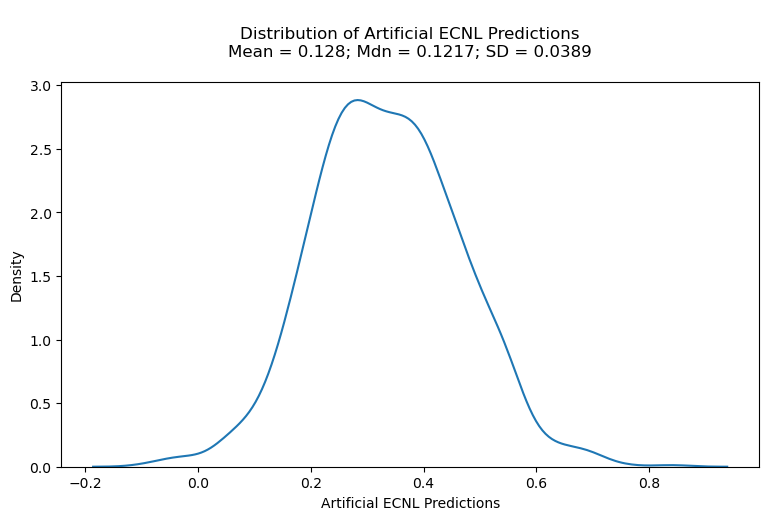

In [16]:
list_flt_ecnl = list(df['ecnl'])
flt_mean = np.mean(list_flt_ecnl)
flt_mdn = np.median(list_flt_ecnl)
flt_sd = np.std(list_flt_ecnl)
fig, ax = plt.subplots(figsize=(9,5))
str_title = f"""
Distribution of Artificial ECNL Predictions
Mean = {flt_mean:0.4}; Mdn = {flt_mdn:0.4f}; SD = {flt_sd:0.4f}
"""
ax.set_title(str_title)
ax.set_xlabel('Artificial ECNL Predictions')
sns.kdeplot(list_flt_pd, ax=ax)
plt.show()

### Solve for multiplicative pricing constant using mean PD and mean LGD

In [18]:
flt_pricing_constant = flt_loss_from_dmr / flt_mean_pd / flt_mean_lgd
print(f'Multiplicative Pricing Constant: {flt_pricing_constant:0.4f}')

Multiplicative Pricing Constant: 1.4347


In [21]:
# assign
df.drop(['additive_constant', 'ecnl'], axis=1, inplace=True)
df['multiplicative_constant'] = flt_pricing_constant
df

,yhat_pd,lgd,multiplicative_constant
0,0.287467,0.139553,1.43472
1,0.388323,0.174541,1.43472
2,0.289419,0.050810,1.43472
3,0.383022,0.229991,1.43472
4,0.290571,0.181166,1.43472
...,...,...,...
995,0.458516,0.173443,1.43472
996,0.282687,0.190736,1.43472
997,0.547795,0.289395,1.43472
998,0.340860,0.091038,1.43472


### Get ECNL

In [22]:
df['ecnl'] = df['yhat_pd'] * df['lgd'] * df['multiplicative_constant']
df

,yhat_pd,lgd,multiplicative_constant,ecnl
0,0.287467,0.139553,1.43472,0.057557
1,0.388323,0.174541,1.43472,0.097243
2,0.289419,0.050810,1.43472,0.021098
3,0.383022,0.229991,1.43472,0.126387
4,0.290571,0.181166,1.43472,0.075526
...,...,...,...,...
995,0.458516,0.173443,1.43472,0.114098
996,0.282687,0.190736,1.43472,0.077358
997,0.547795,0.289395,1.43472,0.227445
998,0.340860,0.091038,1.43472,0.044521


### Plot ECNL

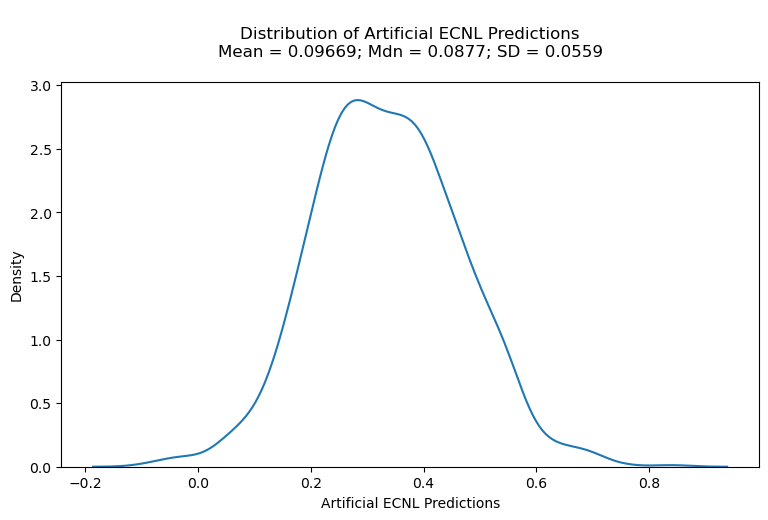

In [23]:
list_flt_ecnl = list(df['ecnl'])
flt_mean = np.mean(list_flt_ecnl)
flt_mdn = np.median(list_flt_ecnl)
flt_sd = np.std(list_flt_ecnl)
fig, ax = plt.subplots(figsize=(9,5))
str_title = f"""
Distribution of Artificial ECNL Predictions
Mean = {flt_mean:0.4}; Mdn = {flt_mdn:0.4f}; SD = {flt_sd:0.4f}
"""
ax.set_title(str_title)
ax.set_xlabel('Artificial ECNL Predictions')
sns.kdeplot(list_flt_pd, ax=ax)
plt.show()